# Data Visualisation — Original vs Cropped

One example per class showing the raw microscopy image alongside the nucleus-cropped version produced by `apply_wbc_crop_robust`.

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import cv2

TRAIN_DIR  = "./train"
CROP_DIR   = "./data_cropped/train"
TRAIN_META = "./train_metadata.csv"

CLASS_NAMES = ['BA', 'BL', 'BNE', 'EO', 'LY', 'MMY', 'MO', 'MY', 'PC', 'PLY', 'PMY', 'SNE', 'VLY']

# Full names for display
FULL_NAMES = {
    'BA':  'Basophil',
    'BL':  'Blast',
    'BNE': 'Band Neutrophil',
    'EO':  'Eosinophil',
    'LY':  'Lymphocyte',
    'MMY': 'Metamyelocyte',
    'MO':  'Monocyte',
    'MY':  'Myelocyte',
    'PC':  'Plasma Cell',
    'PLY': 'Prolymphocyte',
    'PMY': 'Promyelocyte',
    'SNE': 'Segmented Neutrophil',
    'VLY': 'Variant Lymphocyte',
}

CLASS_COUNTS = {
    'BA': 415, 'BL': 2012, 'BNE': 391, 'EO': 861, 'LY': 8101,
    'MMY': 360, 'MO': 2746, 'MY': 441, 'PC': 68, 'PLY': 11,
    'PMY': 114, 'SNE': 13015, 'VLY': 366,
}

train_df = pd.read_csv(TRAIN_META)

In [7]:
def apply_wbc_crop_robust(img_rgb: np.ndarray, fixed_size: int = 280) -> np.ndarray:
    h, w = img_rgb.shape[:2]
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    mask = ((img_hsv[:, :, 1] > 50) & (img_hsv[:, :, 2] < 190)).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    num, _, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num <= 1:
        return img_rgb
    img_center = np.array([w / 2, h / 2])
    best_idx, min_dist = -1, float('inf')
    for i in range(1, num):
        if stats[i, cv2.CC_STAT_AREA] < 400:
            continue
        dist = np.linalg.norm(centroids[i] - img_center)
        if dist < min_dist:
            min_dist = dist
            best_idx = i
    if best_idx == -1:
        return img_rgb
    cx, cy = int(centroids[best_idx][0]), int(centroids[best_idx][1])
    half_s = fixed_size // 2
    x1, x2 = cx - half_s, cx + half_s
    y1, y2 = cy - half_s, cy + half_s
    if x1 < 0:  x2 -= x1; x1 = 0
    if y1 < 0:  y2 -= y1; y1 = 0
    if x2 > w:  x1 -= (x2 - w); x2 = w
    if y2 > h:  y1 -= (y2 - h); y2 = h
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    return img_rgb[y1:y2, x1:x2]

In [8]:
# Pick one representative image per class (fixed seed for reproducibility)
rng = np.random.default_rng(7)
samples = {}
for cls in CLASS_NAMES:
    rows = train_df[train_df['label'] == cls]
    samples[cls] = rows.sample(1, random_state=int(rng.integers(1_000_000))).iloc[0]['ID']

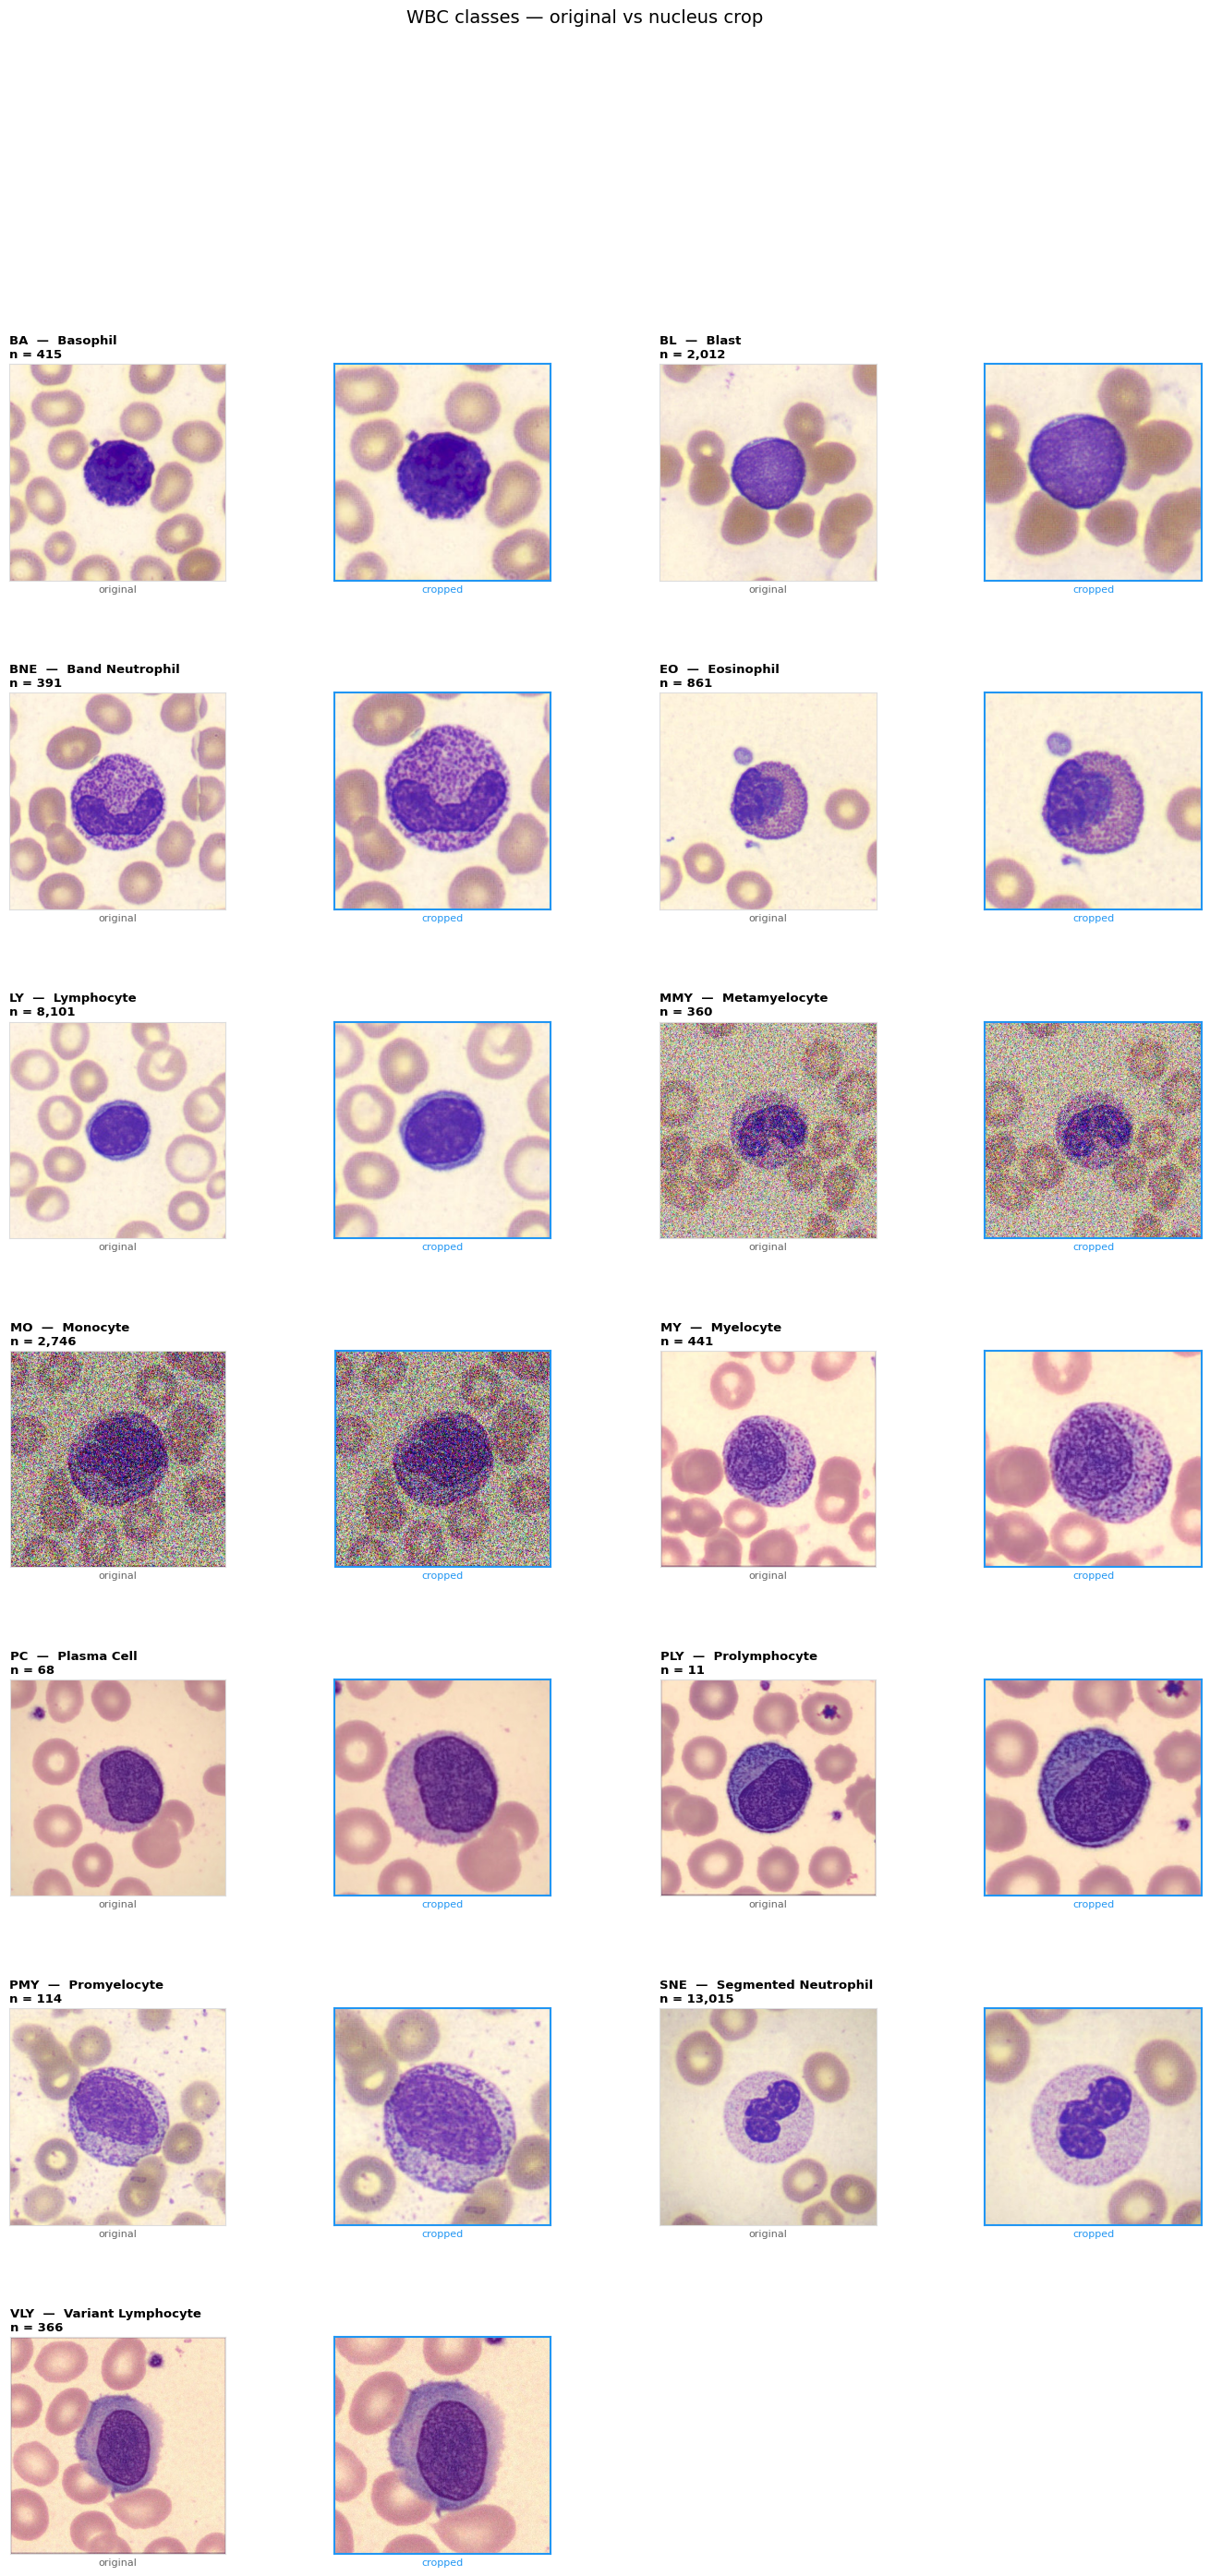

Saved visualisation_orig_vs_crop.png


In [9]:
import math

# Layout: 2 classes per row, 4 columns — [orig_A | crop_A || orig_B | crop_B]
n_rows = math.ceil(len(CLASS_NAMES) / 2)

fig, axes = plt.subplots(
    n_rows, 4,
    figsize=(18, n_rows * 4.4),
    gridspec_kw={'wspace': 0.04, 'hspace': 0.52},
)

def style_ax(ax, highlight=False):
    ax.set_xticks([]); ax.set_yticks([])
    color = '#2196F3' if highlight else '#dddddd'
    lw    = 1.5       if highlight else 0.8
    for sp in ax.spines.values():
        sp.set_edgecolor(color)
        sp.set_linewidth(lw)

for i, cls in enumerate(CLASS_NAMES):
    row = i // 2
    col = (i % 2) * 2      # left pair starts at col 0, right pair at col 2

    img_id  = samples[cls]
    raw_img = np.array(Image.open(os.path.join(TRAIN_DIR, img_id)).convert('RGB'))
    cropped = apply_wbc_crop_robust(raw_img)

    ax_orig = axes[row, col]
    ax_crop = axes[row, col + 1]

    ax_orig.imshow(raw_img)
    ax_orig.set_title(
        f"{cls}  —  {FULL_NAMES[cls]}\nn = {CLASS_COUNTS[cls]:,}",
        fontsize=9.5, fontweight='bold', pad=5, loc='left'
    )
    ax_orig.set_xlabel('original', fontsize=8, labelpad=3, color='#666666')
    style_ax(ax_orig, highlight=False)

    ax_crop.imshow(cropped)
    ax_crop.set_xlabel('cropped', fontsize=8, labelpad=3, color='#2196F3')
    style_ax(ax_crop, highlight=True)

# hide the two unused slots in the last row (13 classes → odd)
if len(CLASS_NAMES) % 2 == 1:
    axes[-1, 2].set_visible(False)
    axes[-1, 3].set_visible(False)

fig.suptitle('WBC classes — original vs nucleus crop', fontsize=14, y=1.005)
plt.savefig('visualisation_orig_vs_crop.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved visualisation_orig_vs_crop.png')

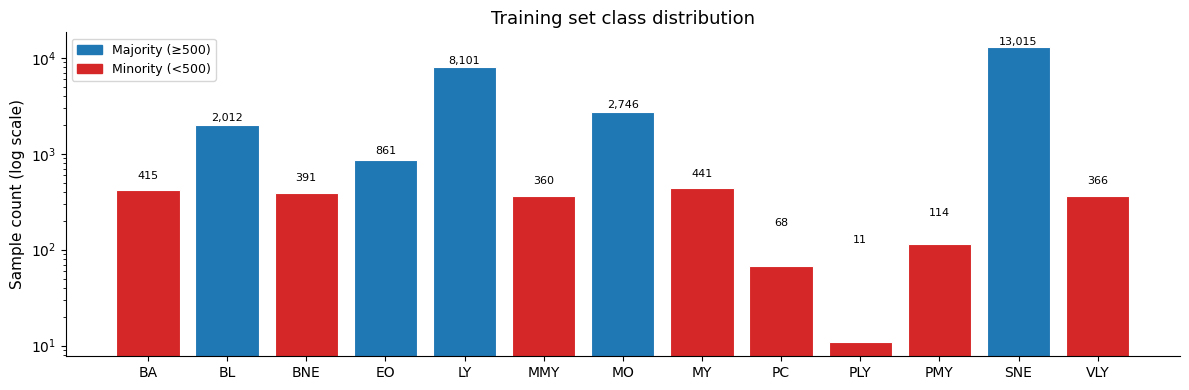

In [10]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(12, 4))
counts = [CLASS_COUNTS[c] for c in CLASS_NAMES]
colors = ['#d62728' if CLASS_COUNTS[c] < 500 else '#1f77b4' for c in CLASS_NAMES]

bars = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{count:,}', ha='center', va='bottom', fontsize=8)

ax.set_yscale('log')
ax.set_ylabel('Sample count (log scale)', fontsize=11)
ax.set_title('Training set class distribution', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#1f77b4', label='Majority (≥500)'),
    Patch(color='#d62728', label='Minority (<500)'),
], fontsize=9)

plt.tight_layout()
plt.savefig('visualisation_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()